# Phishing Website Detection with Cost-Sensitive Evaluation

## Goal

This notebook builds a supervised machine learning model that classifies webpages as phishing or legitimate.

The project focuses on:

- binary classification
- URL and webpage feature analysis
- baseline comparison
- logistic regression
- random forest
- histogram gradient boosting
- recall-focused evaluation
- F2-score model selection
- classification threshold tuning
- missed-phishing analysis
- permutation feature importance

## Main question

Can extracted webpage features identify phishing pages while keeping the number of missed phishing cases low?

In [2]:
import warnings
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    make_scorer
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [3]:
dataset_path = kagglehub.dataset_download(
    "shashwatwork/web-page-phishing-detection-dataset"
)

dataset_path = Path(dataset_path)

print("Dataset downloaded to:", dataset_path)

csv_files = list(dataset_path.rglob("*.csv"))
csv_files

100%|██████████| 1.01M/1.01M [00:00<00:00, 1.08MB/s]

Extracting files...
Dataset downloaded to: C:\Users\ADMIN\.cache\kagglehub\datasets\shashwatwork\web-page-phishing-detection-dataset\versions\2


[WindowsPath('C:/Users/ADMIN/.cache/kagglehub/datasets/shashwatwork/web-page-phishing-detection-dataset/versions/2/dataset_phishing.csv')]

In [4]:
if not csv_files:
    raise FileNotFoundError("No CSV files were found in the downloaded dataset.")

for file in csv_files:
    print(file.name, file.stat().st_size)

dataset_phishing.csv 3661166


In [5]:
# Select the largest CSV in case the download contains multiple files.
csv_path = max(csv_files, key=lambda file: file.stat().st_size)

df = pd.read_csv(csv_path)

print("Loaded:", csv_path.name)
print("Shape:", df.shape)

df.head()

Loaded: dataset_phishing.csv
Shape: (11430, 89)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [6]:
def clean_column_name(column):
    return (
        column.strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )


df.columns = [clean_column_name(column) for column in df.columns]

df.head()

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  str    
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde                    11430 non-null  int64  
 13  nb_percent                  11430 non-null

## Data loading 

The phishing webpage dataset loaded successfully with 11,430 rows and 89 columns.

Each row represents one webpage. The dataset contains:

- one raw URL column
- 87 extracted URL, domain, HTML, and external-service features
- one target column named `status`

All columns were fully populated, so the original dataset contained no missing values.

In [8]:
target_candidates = [
    "status",
    "label",
    "class",
    "target",
    "result"
]

target_col = next(
    (column for column in target_candidates if column in df.columns),
    None
)

if target_col is None:
    raise KeyError(
        f"Target column not found. Available columns: {df.columns.tolist()}"
    )

print("Target column:", target_col)
print(df[target_col].value_counts(dropna=False))

Target column: status
status
legitimate    5715
phishing      5715
Name: count, dtype: int64


In [9]:
target_text = (
    df[target_col]
    .astype(str)
    .str.strip()
    .str.lower()
)

target_mapping = {
    "legitimate": 0,
    "phishing": 1
}

y = target_text.map(target_mapping)

if y.isna().any():
    raise ValueError(
        "Unexpected target values found: "
        f"{target_text[y.isna()].unique().tolist()}"
    )

print(y.value_counts())
print(y.value_counts(normalize=True))

status
0    5715
1    5715
Name: count, dtype: int64
status
0    0.5
1    0.5
Name: proportion, dtype: float64


## Target distribution 

The target contains exactly:

- 5,715 legitimate webpages
- 5,715 phishing webpages

This gives a perfectly balanced class distribution, with a phishing rate of 50%.

Although accuracy is meaningful for this balanced dataset, recall and F2-score remain especially important because a missed phishing page is more costly than an additional false alarm.

In [11]:
possible_identifier_columns = [
    target_col,
    "url",
    "id",
    "index",
    "rowid"
]

drop_columns = [
    column
    for column in possible_identifier_columns
    if column in df.columns
]

drop_columns

['status', 'url']

In [12]:
url_col = "url" if "url" in df.columns else None

X = df.drop(columns=drop_columns).copy()

# Keep only numerical and Boolean predictors.
X = X.select_dtypes(include=["number", "bool"]).copy()

X = X.replace([np.inf, -np.inf], np.nan)

# Remove constant columns.
constant_columns = [
    column
    for column in X.columns
    if X[column].nunique(dropna=False) <= 1
]

X = X.drop(columns=constant_columns)

print("Feature matrix shape:", X.shape)
print("Removed constant columns:", constant_columns)

Feature matrix shape: (11430, 81)
Removed constant columns: ['nb_or', 'ratio_nullhyperlinks', 'ratio_intredirection', 'ratio_interrors', 'submit_email', 'sfh']


## Feature preparation 

The target and raw URL columns were excluded from model training.

Six constant features were also removed because they had no variation and therefore could not help distinguish phishing from legitimate webpages:

- `nb_or`
- `ratio_nullhyperlinks`
- `ratio_intredirection`
- `ratio_interrors`
- `submit_email`
- `sfh`

The final model input contained 81 numerical features.

The raw URL was retained separately for later error analysis, allowing missed phishing webpages to be inspected without using the URL text directly during training.

In [13]:
feature_variation = X.std(numeric_only=True).sort_values(ascending=False)

feature_variation.head(15)

web_traffic                   1.995606e+06
domain_age                    3.107785e+03
domain_registration_length    8.147694e+02
nb_hyperlinks                 1.667583e+02
length_url                    5.529732e+01
ratio_intmedia                4.624990e+01
links_in_tags                 4.152314e+01
safe_anchor                   3.907339e+01
ratio_extmedia                3.838658e+01
longest_word_path             2.307788e+01
longest_words_raw             2.208364e+01
length_hostname               1.077717e+01
avg_word_path                 7.147050e+00
length_words_raw              5.572355e+00
longest_word_host             4.932015e+00
dtype: float64

In [14]:
selected_features = [
    feature
    for feature in [
        "length_url",
        "length_hostname",
        "nb_dots",
        "nb_hyphens",
        "ratio_digits_url",
        "page_rank"
    ]
    if feature in X.columns
]

selected_features

['length_url',
 'length_hostname',
 'nb_dots',
 'nb_hyphens',
 'ratio_digits_url',
 'page_rank']

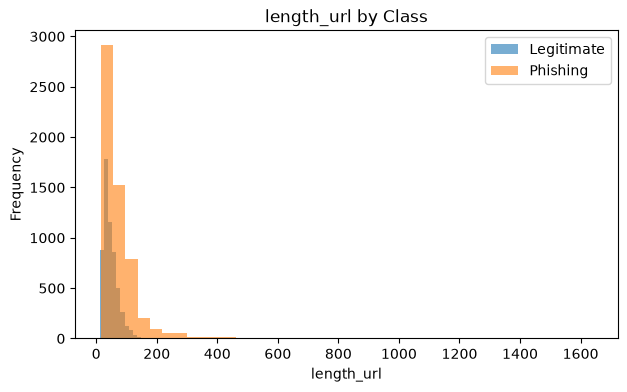

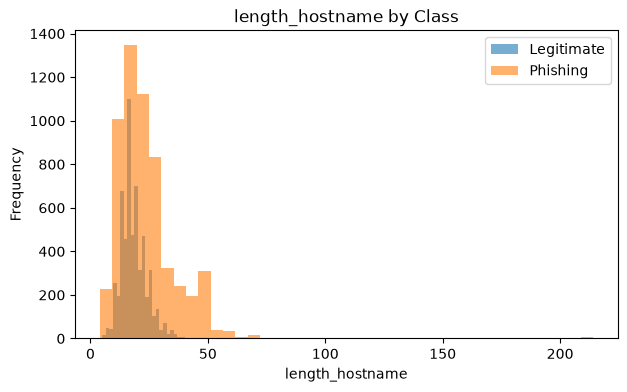

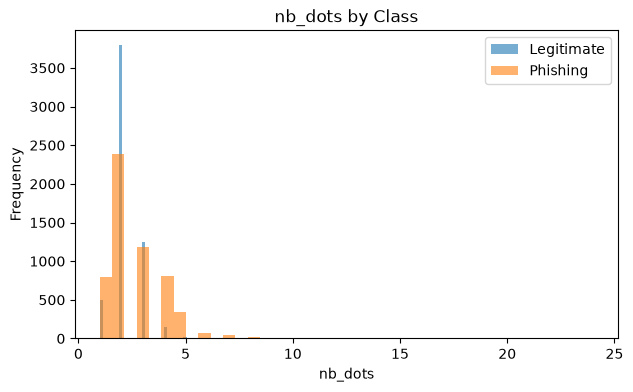

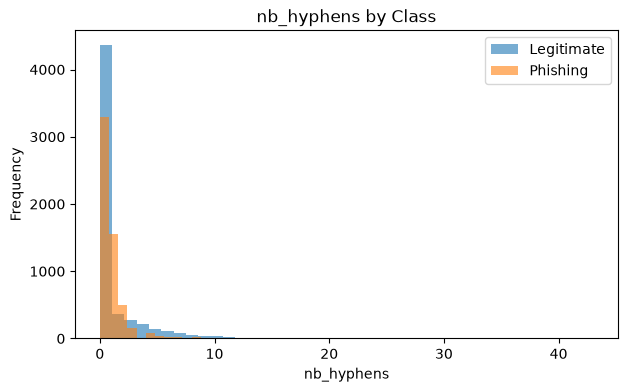

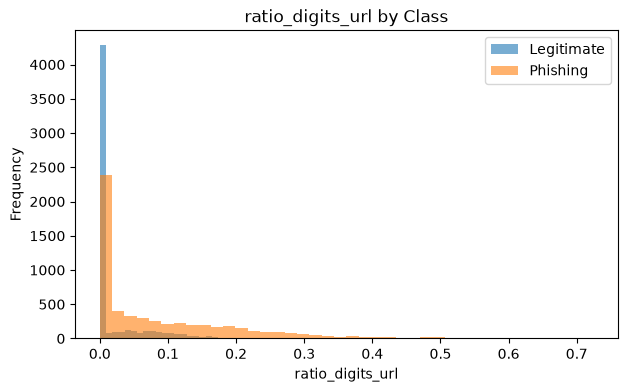

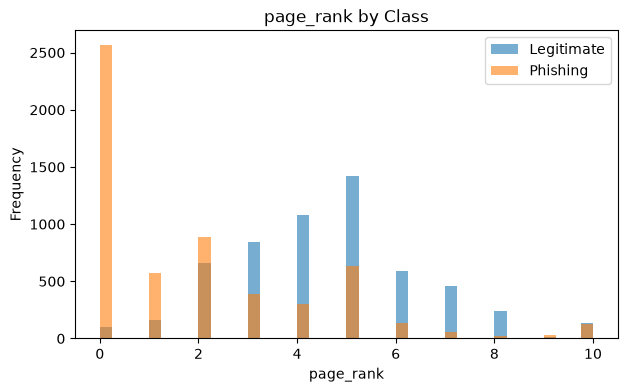

In [15]:
for feature in selected_features:
    plt.figure(figsize=(7, 4))
    
    plt.hist(
        X.loc[y == 0, feature].dropna(),
        bins=40,
        alpha=0.6,
        label="Legitimate"
    )
    
    plt.hist(
        X.loc[y == 1, feature].dropna(),
        bins=40,
        alpha=0.6,
        label="Phishing"
    )
    
    plt.title(f"{feature} by Class")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

## EDA notes

Several feature distributions showed differences between phishing and legitimate webpages.

Phishing webpages generally had:

- longer URLs
- longer hostnames
- more dots in the URL
- a higher proportion of digits in the URL
- lower page-rank values

The clearest individual separation appeared in `page_rank`. Many phishing webpages had a page rank near zero, while legitimate webpages were more common at higher page-rank values.

However, the classes still overlapped for every individual feature. This shows that phishing detection requires combining multiple weak indicators rather than relying on one simple rule.

In [16]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print("\nPhishing rates:")
print("Train:", y_train.mean())
print("Validation:", y_val.mean())
print("Test:", y_test.mean())

Training set: (6858, 81)
Validation set: (2286, 81)
Test set: (2286, 81)

Phishing rates:
Train: 0.5
Validation: 0.5
Test: 0.5


## Split strategy 

A stratified train, validation, and test split was used.

The resulting datasets were:

- Training set: 6,858 webpages
- Validation set: 2,286 webpages
- Test set: 2,286 webpages

Each split maintained a phishing rate of exactly 50%.

The validation set was used for model comparison and threshold selection, while the test set remained untouched until the final evaluation.

In [17]:
def get_positive_scores(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_data)
        return 1 / (1 + np.exp(-scores))
    
    raise AttributeError("Model does not provide probability-like scores.")

In [18]:
def evaluate_predictions(
    y_true,
    y_pred,
    y_score=None,
    model_name="Model"
):
    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(
            y_true,
            y_pred,
            beta=2,
            zero_division=0
        )
    }
    
    if y_score is not None:
        result["roc_auc"] = roc_auc_score(y_true, y_score)
        result["average_precision"] = average_precision_score(
            y_true,
            y_score
        )
    
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    
    for metric, value in result.items():
        if metric != "model":
            print(f"{metric}: {value:.4f}")
    
    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=["Legitimate", "Phishing"],
            zero_division=0
        )
    )
    
    cm = confusion_matrix(y_true, y_pred)
    
    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legitimate", "Phishing"]
    )
    
    display.plot()
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()
    
    return result

In [19]:
def find_best_f2_threshold(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(
        y_true,
        y_score
    )
    
    precision = precision[:-1]
    recall = recall[:-1]
    
    f2_scores = (
        5 * precision * recall
        / (4 * precision + recall + 1e-10)
    )
    
    best_index = np.argmax(f2_scores)
    
    return {
        "threshold": thresholds[best_index],
        "precision": precision[best_index],
        "recall": recall[best_index],
        "f2": f2_scores[best_index]
    }

Dummy Baseline
accuracy: 0.5000
balanced_accuracy: 0.5000
precision: 0.0000
recall: 0.0000
f1: 0.0000
f2: 0.0000

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.50      1.00      0.67      1143
    Phishing       0.00      0.00      0.00      1143

    accuracy                           0.50      2286
   macro avg       0.25      0.50      0.33      2286
weighted avg       0.25      0.50      0.33      2286



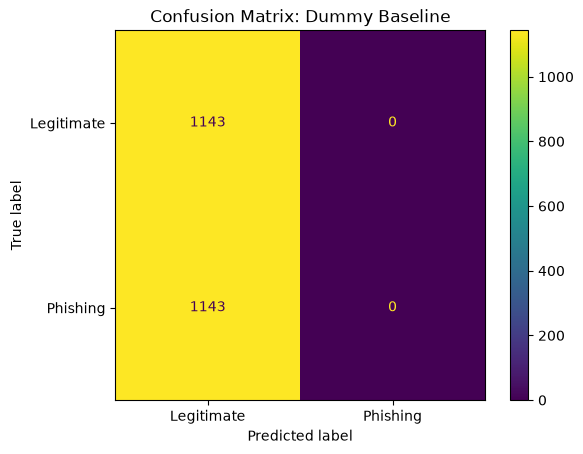

In [20]:
baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline_model.fit(X_train, y_train)

baseline_val_preds = baseline_model.predict(X_val)

baseline_result = evaluate_predictions(
    y_true=y_val,
    y_pred=baseline_val_preds,
    model_name="Dummy Baseline"
)

Logistic Regression
accuracy: 0.9418
balanced_accuracy: 0.9418
precision: 0.9422
recall: 0.9414
f1: 0.9418
f2: 0.9415
roc_auc: 0.9864
average_precision: 0.9874

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.94      0.94      0.94      1143
    Phishing       0.94      0.94      0.94      1143

    accuracy                           0.94      2286
   macro avg       0.94      0.94      0.94      2286
weighted avg       0.94      0.94      0.94      2286



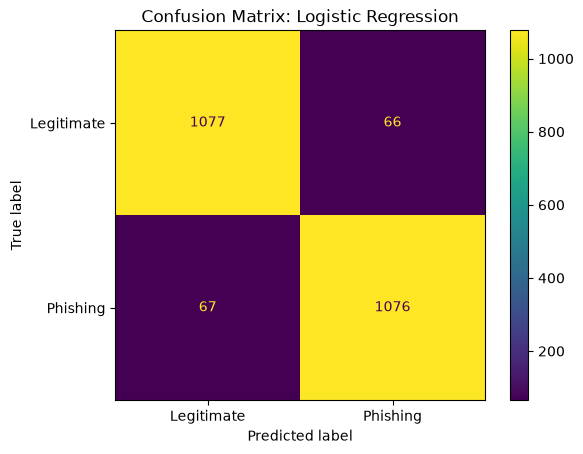

In [21]:
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

logistic_model.fit(X_train, y_train)

logistic_val_scores = get_positive_scores(logistic_model, X_val)
logistic_val_preds = logistic_model.predict(X_val)

logistic_result = evaluate_predictions(
    y_true=y_val,
    y_pred=logistic_val_preds,
    y_score=logistic_val_scores,
    model_name="Logistic Regression"
)

Random Forest
accuracy: 0.9606
balanced_accuracy: 0.9606
precision: 0.9582
recall: 0.9633
f1: 0.9607
f2: 0.9622
roc_auc: 0.9928
average_precision: 0.9933

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.96      0.96      0.96      1143
    Phishing       0.96      0.96      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



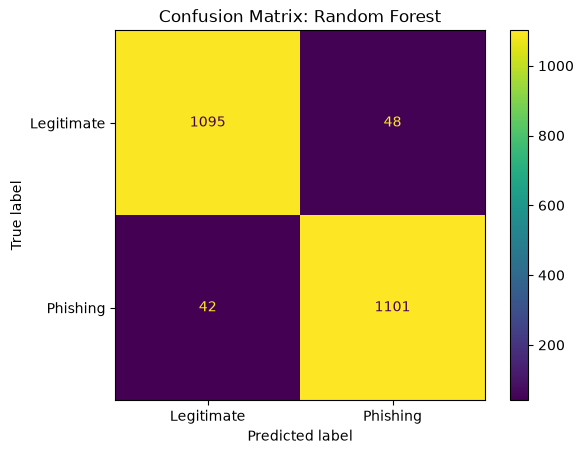

In [22]:
random_forest_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

rf_val_scores = get_positive_scores(random_forest_model, X_val)
rf_val_preds = random_forest_model.predict(X_val)

rf_result = evaluate_predictions(
    y_true=y_val,
    y_pred=rf_val_preds,
    y_score=rf_val_scores,
    model_name="Random Forest"
)

Histogram Gradient Boosting
accuracy: 0.9676
balanced_accuracy: 0.9676
precision: 0.9684
recall: 0.9668
f1: 0.9676
f2: 0.9671
roc_auc: 0.9947
average_precision: 0.9955

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.97      0.97      1143
    Phishing       0.97      0.97      0.97      1143

    accuracy                           0.97      2286
   macro avg       0.97      0.97      0.97      2286
weighted avg       0.97      0.97      0.97      2286



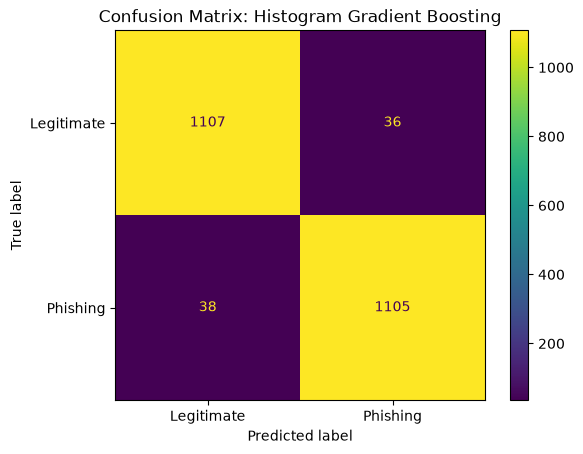

In [23]:
hist_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingClassifier(
        max_iter=250,
        learning_rate=0.08,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    ))
])

hist_model.fit(X_train, y_train)

hist_val_scores = get_positive_scores(hist_model, X_val)
hist_val_preds = hist_model.predict(X_val)

hist_result = evaluate_predictions(
    y_true=y_val,
    y_pred=hist_val_preds,
    y_score=hist_val_scores,
    model_name="Histogram Gradient Boosting"
)

In [24]:
results_df = pd.DataFrame([
    baseline_result,
    logistic_result,
    rf_result,
    hist_result
])

results_df.sort_values("f2", ascending=False)

,model,accuracy,balanced_accuracy,precision,recall,f1,f2,roc_auc,average_precision
3,Histogram Gradient Boosting,0.967629,0.967629,0.968449,0.966754,0.967601,0.967093,0.994727,0.995502
2,Random Forest,0.960630,0.960630,0.958225,0.963255,0.960733,0.962244,0.992828,0.993343
1,Logistic Regression,0.941820,0.941820,0.942207,0.941382,0.941794,0.941547,0.986401,0.987446
0,Dummy Baseline,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,NaN,NaN


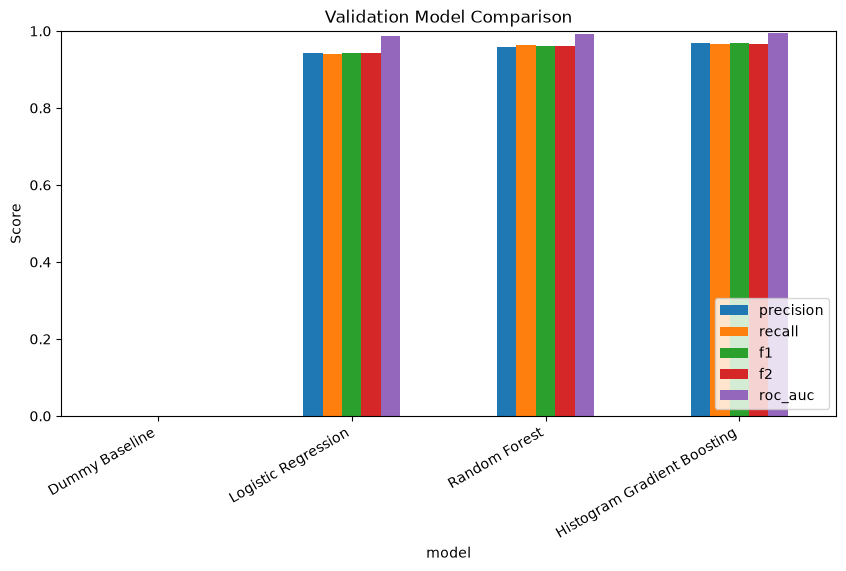

In [25]:
metrics_to_plot = [
    "precision",
    "recall",
    "f1",
    "f2",
    "roc_auc"
]

plot_df = results_df.set_index("model")[metrics_to_plot]

plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Validation Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

## Validation comparison 

Histogram Gradient Boosting was the strongest validation model.

The validation results were:

| Model | Precision | Recall | F1 | F2 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Histogram Gradient Boosting | 0.9684 | 0.9668 | 0.9676 | 0.9671 | 0.9947 |
| Random Forest | 0.9582 | 0.9633 | 0.9607 | 0.9622 | 0.9928 |
| Logistic Regression | 0.9422 | 0.9414 | 0.9418 | 0.9415 | 0.9864 |
| Dummy Baseline | 0.0000 | 0.0000 | 0.0000 | 0.0000 | N/A |

Histogram Gradient Boosting achieved the highest validation F2-score, accuracy, F1-score, ROC-AUC, and average precision.

It was therefore selected for threshold tuning and final test evaluation.

In [26]:
model_lookup = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "Histogram Gradient Boosting": hist_model
}

score_lookup = {
    "Logistic Regression": logistic_val_scores,
    "Random Forest": rf_val_scores,
    "Histogram Gradient Boosting": hist_val_scores
}

best_model_name = (
    results_df[results_df["model"] != "Dummy Baseline"]
    .sort_values("f2", ascending=False)
    .iloc[0]["model"]
)

best_model = model_lookup[best_model_name]
best_val_scores = score_lookup[best_model_name]

print("Best validation model:", best_model_name)

Best validation model: Histogram Gradient Boosting


In [27]:
best_threshold_info = find_best_f2_threshold(
    y_true=y_val,
    y_score=best_val_scores
)

best_threshold_info

{'threshold': np.float64(0.09758155603987755),
 'precision': np.float64(0.9344398340248963),
 'recall': np.float64(0.9851268591426072),
 'f2': np.float64(0.9745542668999124)}

## Threshold tuning 

The F2-optimised classification threshold was approximately 0.0976, which is much lower than the default threshold of 0.5.

On the validation set, the selected threshold achieved:

- Precision: 0.9344
- Recall: 0.9851
- F2-score: 0.9746

Lowering the threshold caused the model to classify more webpages as phishing. This reduced precision slightly but increased recall, which matches the project goal of reducing missed phishing pages.

In [28]:
test_scores = get_positive_scores(best_model, X_test)

test_default_preds = (test_scores >= 0.5).astype(int)

test_tuned_preds = (
    test_scores >= best_threshold_info["threshold"]
).astype(int)

Histogram Gradient Boosting, Default Threshold
accuracy: 0.9659
balanced_accuracy: 0.9659
precision: 0.9626
recall: 0.9694
f1: 0.9660
f2: 0.9680
roc_auc: 0.9940
average_precision: 0.9937

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.96      0.97      1143
    Phishing       0.96      0.97      0.97      1143

    accuracy                           0.97      2286
   macro avg       0.97      0.97      0.97      2286
weighted avg       0.97      0.97      0.97      2286



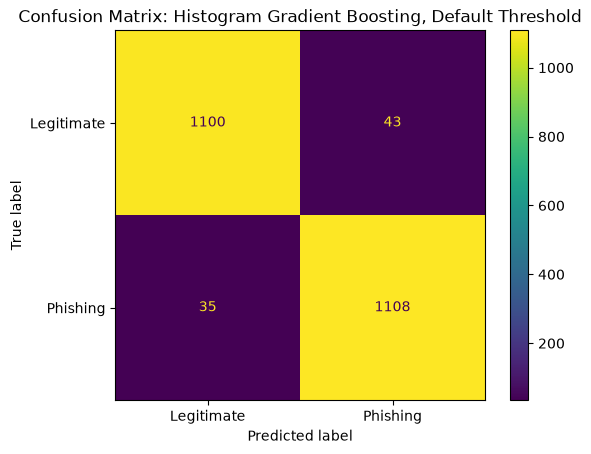

In [29]:
test_default_result = evaluate_predictions(
    y_true=y_test,
    y_pred=test_default_preds,
    y_score=test_scores,
    model_name=f"{best_model_name}, Default Threshold"
)

Histogram Gradient Boosting, Tuned F2 Threshold
accuracy: 0.9545
balanced_accuracy: 0.9545
precision: 0.9304
recall: 0.9825
f1: 0.9557
f2: 0.9716
roc_auc: 0.9940
average_precision: 0.9937

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.93      0.95      1143
    Phishing       0.93      0.98      0.96      1143

    accuracy                           0.95      2286
   macro avg       0.96      0.95      0.95      2286
weighted avg       0.96      0.95      0.95      2286



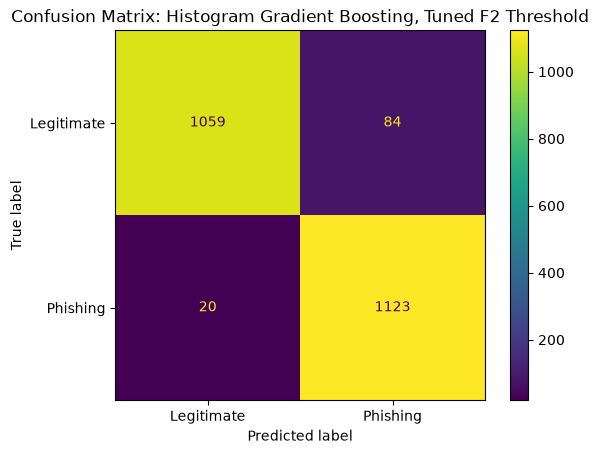

In [30]:
test_tuned_result = evaluate_predictions(
    y_true=y_test,
    y_pred=test_tuned_preds,
    y_score=test_scores,
    model_name=f"{best_model_name}, Tuned F2 Threshold"
)

## Final test result 

Using the default threshold of 0.5, Histogram Gradient Boosting achieved:

- Accuracy: 0.9659
- Precision: 0.9626
- Recall: 0.9694
- F1-score: 0.9660
- F2-score: 0.9680
- ROC-AUC: 0.9940
- Average precision: 0.9937

Using the tuned threshold of 0.0976, it achieved:

- Accuracy: 0.9545
- Balanced accuracy: 0.9545
- Precision: 0.9304
- Recall: 0.9825
- F1-score: 0.9557
- F2-score: 0.9716
- ROC-AUC: 0.9940
- Average precision: 0.9937

Threshold tuning increased phishing recall from 96.94% to 98.25% and improved F2-score from 0.9680 to 0.9716.

In [31]:
test_analysis = pd.DataFrame({
    "true_label": y_test,
    "predicted_label": test_tuned_preds,
    "phishing_probability": test_scores
}, index=X_test.index)

if url_col is not None:
    test_analysis["url"] = df.loc[X_test.index, url_col]

test_analysis["correct"] = (
    test_analysis["true_label"]
    == test_analysis["predicted_label"]
)

missed_phishing = test_analysis[
    (test_analysis["true_label"] == 1)
    & (test_analysis["predicted_label"] == 0)
].sort_values("phishing_probability")

print("Total test phishing pages:", (y_test == 1).sum())
print("Missed phishing pages:", len(missed_phishing))

Total test phishing pages: 1143
Missed phishing pages: 20


In [32]:
display_columns = [
    column
    for column in [
        "url",
        "true_label",
        "predicted_label",
        "phishing_probability"
    ]
    if column in missed_phishing.columns
]

missed_phishing[display_columns].head(15)

,url,true_label,predicted_label,phishing_probability
4275,http://www.vintostal.pl/,1,0,0.000406
7578,http://cashat.pro/,1,0,0.002317
11205,https://www.todosprodutos.com.br,1,0,0.002701
3866,https://buduzdorov.narod.ru/,1,0,0.003155
9204,http://banrisul.com.br/bob/link/bobw00hn_conte...,1,0,0.003202
1914,https://www.namikeystonepa.org/xanax/,1,0,0.008997
3669,http://www.novinroyapolymer.com/,1,0,0.012890
245,http://botforbyks.blogspot.ru/,1,0,0.013216
1900,https://vk.youhack.info,1,0,0.013299
1714,https://www.lmzrb.com,1,0,0.014282


## Missed phishing analysis 

The test set contained 1,143 phishing webpages.

With the tuned threshold, the final model missed only 20 phishing webpages. This corresponds to a phishing false-negative rate of approximately 1.75%.

By comparison, the default threshold missed 35 phishing webpages. Threshold tuning therefore prevented 15 additional phishing pages from being classified as legitimate.

Several missed phishing webpages received extremely low phishing probabilities. For example, some had probabilities below 0.01, showing that the model was confidently wrong in those cases.

These false negatives are the most important errors because they represent malicious webpages that could pass through the detector without a warning.

In [33]:
f2_scorer = make_scorer(
    fbeta_score,
    beta=2,
    zero_division=0
)

perm_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring=f2_scorer,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_result.importances_mean,
    "std": perm_result.importances_std
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance,std
80,page_rank,0.048004,0.003626
79,google_index,0.032472,0.004656
19,nb_www,0.021710,0.002800
4,nb_hyphens,0.007641,0.001234
55,nb_hyperlinks,0.007515,0.001315
76,domain_age,0.006258,0.003045
49,phish_hints,0.005041,0.002001
12,nb_slash,0.003825,0.001345
41,shortest_word_host,0.002165,0.000993
1,length_hostname,0.002017,0.000633


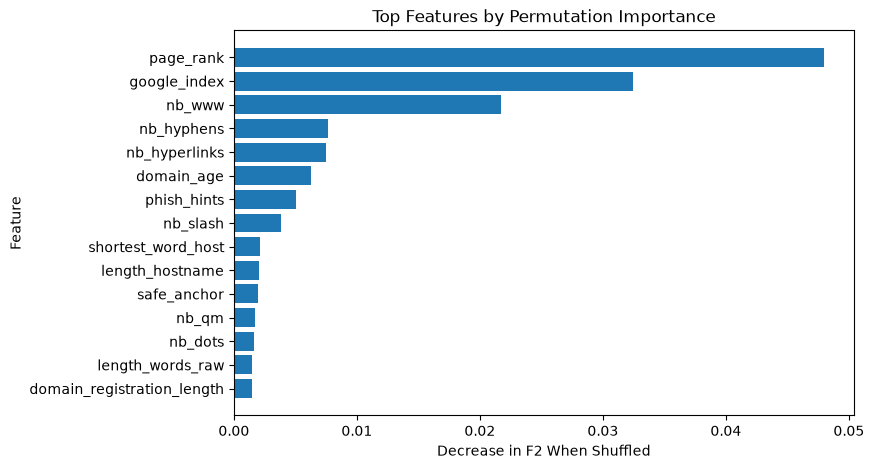

In [34]:
top_features = importance_df.head(15)

plt.figure(figsize=(8, 5))
plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)
plt.title("Top Features by Permutation Importance")
plt.xlabel("Decrease in F2 When Shuffled")
plt.ylabel("Feature")
plt.show()

## Feature importance 

The most important features according to permutation importance were:

1. `page_rank`
2. `google_index`
3. `nb_www`
4. `nb_hyphens`
5. `nb_hyperlinks`
6. `domain_age`
7. `phish_hints`
8. `nb_slash`
9. `shortest_word_host`
10. `length_hostname`

`page_rank` was the strongest feature by a clear margin, followed by whether the webpage appeared in the Google index.

This suggests that external reputation and visibility signals were highly useful for phishing detection. URL structure, hostname characteristics, domain age, hyperlink counts, and known phishing hints also contributed to the model.

A practical limitation is that external-service features such as page rank and Google indexing may not always be immediately available for newly created webpages. A real-time system should also be tested without these features.